### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [4]:
data = pd.read_csv('coupons.csv')

In [ ]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [5]:
data.isnull().sum()

,0
destination,0
passanger,0
weather,0
temperature,0
time,0
coupon,0
expiration,0
gender,0
age,0
maritalStatus,0


The dataset contains missing values in several columns. The car column has the highest number of missing values with 12,576 missing entries. Other columns such as CoffeeHouse, CarryAway, RestaurantLessThan20, and Restaurant20To50 also contain some missing data. Most of the remaining columns do not have missing values.

In [6]:
data.shape

(12684, 26)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

3. Decide what to do about your missing data -- drop, replace, other...

In [8]:
data = data.drop(columns=['car'])

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  Bar                   12577 non-null  object
 15  CoffeeHouse           12467 non-null

The car column was dropped because it contained too many missing values to be useful for analysis. The remaining missing values in other columns were relatively small compared to the dataset size and were kept for now.

4. What proportion of the total observations chose to accept the coupon?



In [10]:
data['Y'].mean()

np.float64(0.5684326710816777)

Approximately 56% of the customers accepted the coupon offer.

5. Use a bar plot to visualize the `coupon` column.

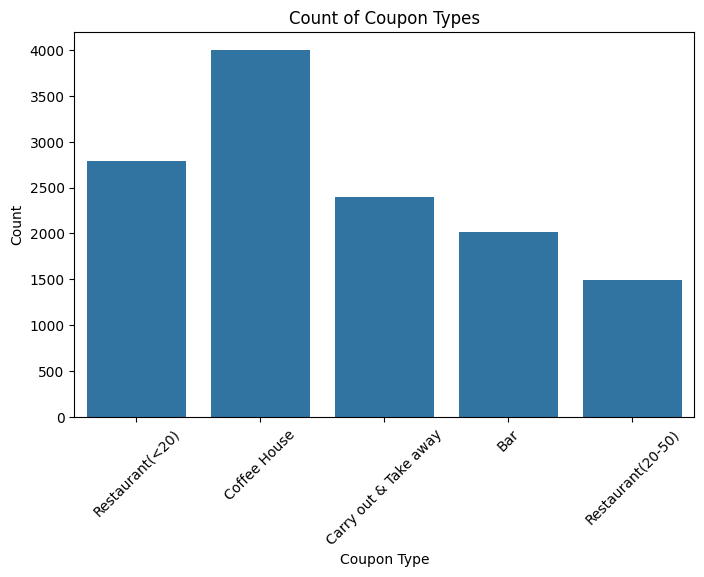

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(data=data, x='coupon')
plt.title('Count of Coupon Types')
plt.xlabel('Coupon Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

This bar chart shows the number of observations for each coupon type. Coffee House and Restaurant(<20) coupons appear most frequently in the dataset.

6. Use a histogram to visualize the temperature column.

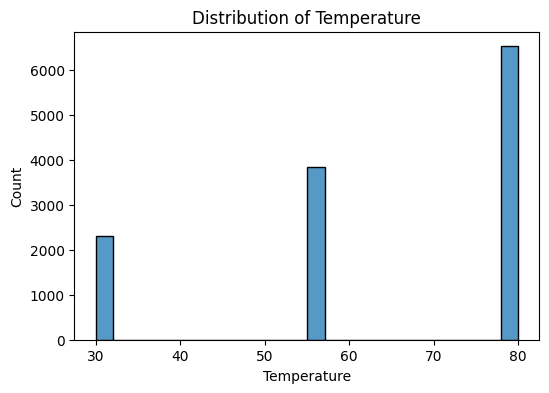

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(data=data, x='temperature')
plt.title('Distribution of Temperature')
plt.xlabel('Temperature')
plt.ylabel('Count')
plt.show()

The histogram shows that the temperature variable contains three main temperature values: 30°F, 55°F, and 80°F. The most common temperature in the dataset is 80°F, followed by 55°F and 30°F. This indicates that the data was collected using a few predefined temperature categories rather than a continuous range of temperatures.

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [13]:
bar = data[data['coupon'] == 'Bar']

In [14]:
bar.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
9,No Urgent Place,Kid(s),Sunny,80,10AM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
13,Home,Alone,Sunny,55,6PM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,1,0,1
17,Work,Alone,Sunny,55,7AM,Bar,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,1,0,1,0
24,No Urgent Place,Friend(s),Sunny,80,10AM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,0,1,1
35,Home,Alone,Sunny,55,6PM,Bar,1d,Male,21,Single,...,less1,4~8,4~8,less1,1,0,0,1,0,1


2. What proportion of bar coupons were accepted?


In [15]:
bar['Y'].mean()

np.float64(0.41001487357461575)

Approximately 41% of customers accepted a Bar coupon.

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [16]:
bar['Bar'].value_counts()

,count
Bar,
never,830
less1,570
1~3,397
4~8,150
gt8,49


In [19]:
bar_3_or_less = bar[bar['Bar'].isin(['never', 'less1', '1-3'])]
bar_more_than_3 = bar[bar['Bar'].isin(['4-8', 'gt8'])]

print("3 or fewer visits:", bar_3_or_less['Y'].mean())
print("More than 3 visits:", bar_more_than_3['Y'].mean())

3 or fewer visits: 0.29214285714285715
More than 3 visits: 0.7346938775510204


Customers who visited a bar more than 3 times per month had a significantly higher coupon acceptance rate (73.5%) compared to customers who visited a bar 3 or fewer times per month (29.2%). This suggests that frequent bar-goers are much more likely to accept Bar coupons.

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [20]:
group1 = bar[(bar['Bar'].isin(['1~3', '4~8', 'gt8'])) & (bar['age'].isin(['26', '31', '36', '41', '46', '50plus']))]
group2 = bar.drop(group1.index)

print("Over 25 and goes to bar more than once a month:", group1['Y'].mean())
print("All others:", group2['Y'].mean())

Over 25 and goes to bar more than once a month: 0.6952380952380952
All others: 0.33500313087038197


Drivers who are over 25 and go to a bar more than once a month had a much higher Bar coupon acceptance rate at 69.5%, compared to 33.5% for all other drivers. This shows a clear difference and suggests that frequent bar goers over 25 are more likely to accept Bar coupons.

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [22]:
group1 = bar[(bar['Bar'].isin(['1~3', '4~8', 'gt8'])) & (bar['passanger'] != 'Kid(s)') & (bar['occupation'] != 'Farming Fishing & Forestry')]

group2 = bar.drop(group1.index)

print("Target group:", group1['Y'].mean())
print("All others:", group2['Y'].mean())

Target group: 0.7132486388384754
All others: 0.296043656207367


Drivers who go to bars more than once a month, do not have kids as passengers, and are not in Farming/Fishing/Forestry had a much higher acceptance rate at 71.3%, compared to 29.6% for all others. This suggests this target group is more likely to accept Bar coupons.

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [23]:
group1 = bar[
    (bar['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar['passanger'] != 'Kid(s)') &
    (bar['maritalStatus'] != 'Widowed')
]

group2 = bar[
    (bar['Bar'].isin(['1~3', '4~8', 'gt8'])) &
    (bar['age'].isin(['21', 'below21', '26']))
]

group3 = bar[
    (bar['RestaurantLessThan20'].isin(['4~8', 'gt8'])) &
    (bar['income'].isin(['Less than $12500', '$12500 - $24999', '$25000 - $37499', '$37500 - $49999']))
]

print("Group 1:", group1['Y'].mean())
print("Group 2:", group2['Y'].mean())
print("Group 3:", group3['Y'].mean())

Group 1: 0.7132486388384754
Group 2: 0.7217391304347827
Group 3: 0.45348837209302323


Group 2 had the highest coupon acceptance rate at 72.2%, followed closely by Group 1 at 71.3%. Group 3 had a lower acceptance rate of 45.3%. These results suggest that younger drivers who visit bars more than once a month are the most likely to accept Bar coupons. Drivers who frequently visit bars, are not traveling with children, and are not widowed also show a high likelihood of accepting Bar coupons.

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

Based on the analysis, I hypothesize that drivers who frequently visit bars are significantly more likely to accept Bar coupons than those who rarely visit bars. Customers who visited bars more than three times per month had an acceptance rate of 73.5%, compared to only 29.2% for those who visited bars three or fewer times per month. Drivers over the age of 25 who visited bars more than once a month also showed a high acceptance rate of 69.5%. Additionally, drivers who frequently visited bars, did not have children as passengers, and were not widowed had acceptance rates above 70%. These findings suggest that prior bar-going behavior is the strongest indicator of whether a driver will accept a Bar coupon.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

In [26]:
rest20 = data[data['coupon'] == 'Restaurant(<20)']

In [27]:
rest20.shape

(2786, 25)

In [28]:
rest20['Y'].mean()

np.float64(0.7071069633883704)

Approximately 70% of customers accepted Restaurant(<20) coupons.

In [29]:
rest20.groupby('RestaurantLessThan20')['Y'].mean().sort_values()

,Y
RestaurantLessThan20,
never,0.555556
less1,0.673913
1~3,0.702679
4~8,0.717500
gt8,0.760417


As restaurant visits increase, coupon acceptance generally increases. People who never go to inexpensive restaurants accepted the coupon only 55.6% of the time. People who visit inexpensive restaurants more than 8 times per month accepted the coupon 76.0% of the time. This is exactly the same type of pattern we found with Bar coupons which is people who already engage in the activity are more likely to accept a coupon related to that activity.

In [30]:
rest20.groupby('age')['Y'].mean().sort_values()

,Y
age,
50plus,0.637755
36,0.651877
31,0.705357
41,0.708502
26,0.730838
below21,0.734375
21,0.741652
46,0.756757


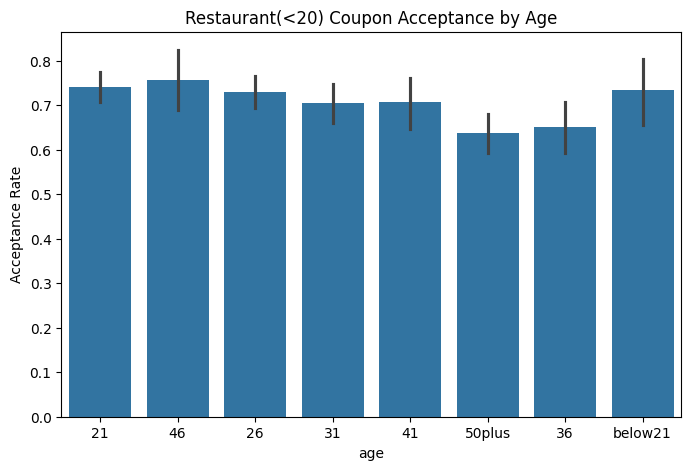

In [31]:
plt.figure(figsize=(8,5))
sns.barplot(data=rest20, x='age', y='Y')
plt.title('Restaurant(<20) Coupon Acceptance by Age')
plt.ylabel('Acceptance Rate')
plt.show()

While there are some differences in coupon acceptance across age groups, there does not appear to be a strong or consistent relationship between age and Restaurant(<20) coupon acceptance. Acceptance rates remain relatively high across most age groups, suggesting that age is not as strong a predictor as restaurant visitation frequency.

In [32]:
rest20.groupby('income')['Y'].mean().sort_values()

,Y
income,
$87500 - $99999,0.577889
$75000 - $87499,0.661458
$37500 - $49999,0.681818
$12500 - $24999,0.685000
$62500 - $74999,0.696809
$100000 or More,0.717678
Less than $12500,0.724138
$25000 - $37499,0.753363
$50000 - $62499,0.782486


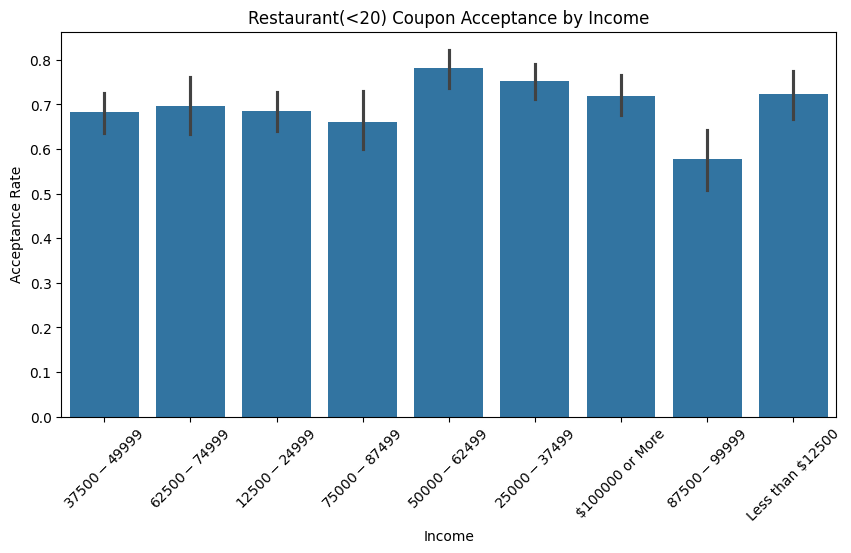

In [33]:
plt.figure(figsize=(10,5))
sns.barplot(data=rest20, x='income', y='Y')
plt.title('Restaurant(<20) Coupon Acceptance by Income')
plt.xlabel('Income')
plt.ylabel('Acceptance Rate')
plt.xticks(rotation=45)
plt.show()

Income appears to have some influence on Restaurant(<20) coupon acceptance, but the relationship is not linear. Both lower-income and higher-income groups show relatively high acceptance rates, suggesting that income alone is not the primary driver of coupon acceptance. Customer dining behavior appears to be a stronger predictor as seen before.

In [34]:
young_frequent = rest20[(rest20['RestaurantLessThan20'].isin(['4~8','gt8'])) & (rest20['age'].isin(['below21','21','26']))]

others = rest20.drop(young_frequent.index)

print("Young frequent visitors:", young_frequent['Y'].mean())
print("Others:", others['Y'].mean())

Young frequent visitors: 0.7567567567567568
Others: 0.6967462039045553



Young customers who frequently visit inexpensive restaurants had a higher acceptance rate at 75.7%, compared to 69.7% for all others. However, the difference is not as large as the difference seen in the Bar coupon analysis. This suggests that for Restaurant(<20) coupons, frequent restaurant visits are a stronger predictor than age alone.

In [37]:
friends_group = rest20[(rest20['RestaurantLessThan20'].isin(['4~8','gt8'])) &(rest20['passanger'] == 'Friend(s)')]

others = rest20.drop(friends_group.index)

print("Frequent visitors with friends:", friends_group['Y'].mean())
print("Others:", others['Y'].mean())

Frequent visitors with friends: 0.8184713375796179
Others: 0.6929611650485437


Customers who frequently visited inexpensive restaurants and were traveling with friends had an acceptance rate of 81.8%, compared to 69.3% for all other customers. This suggests that social dining situations may increase the likelihood of accepting Restaurant(<20) coupons.

In [38]:
lunch_dinner = rest20[(rest20['RestaurantLessThan20'].isin(['4~8','gt8'])) & (rest20['time'].isin(['2PM','6PM','10PM']))]

others = rest20.drop(lunch_dinner.index)

print("Frequent visitors during meal times:", lunch_dinner['Y'].mean())
print("Others:", others['Y'].mean())

Frequent visitors during meal times: 0.7654155495978552
Others: 0.6857843137254902


Customers who frequently visited inexpensive restaurants and received the coupon during common meal times (2 PM, 6 PM, or 10 PM) had an acceptance rate of 76.5%, compared to 68.6% for all other customers. This indicates that timing may play a role in coupon acceptance, with customers being more receptive to restaurant offers when they are closer to dining occasions.

**In Conclusion:** For my independent investigation, I analyzed Restaurant(<20) coupons to identify the characteristics of customers who were most likely to accept them. I found that customers who frequently visited inexpensive restaurants had higher coupon acceptance rates than those who rarely visited these restaurants. I also found that customers who frequently visited inexpensive restaurants and were traveling with friends had the highest acceptance rate (81.8%), suggesting that social dining situations may increase coupon usage. Additionally, customers who frequently visited inexpensive restaurants and received the coupon during common meal times showed higher acceptance rates than other customers. Overall, the results suggest that prior dining habits and social context are important factors in predicting whether a customer will accept a Restaurant(<20) coupon.